<a href="https://colab.research.google.com/github/Nusrat20448/AI-TPMS-FYP-/blob/Data-Preprocessing/Data_Preprocessing_with_new_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [10]:
data=pd.read_csv('//content/EV_Predictive_Maintenance_Dataset_15min.csv')

In [11]:
import pandas as pd
import numpy as np

# STEP 1: Load your file (Make sure the filename matches your uploaded file!)
# If your variable was called 'data', we will define it here.
try:
    data = pd.read_csv('your_file_name.csv') # Change this to your actual file name
    print("Success: Data loaded!")
except:
    print("Error: File not found. Please upload your CSV to Colab first.")

# STEP 2: Transform into 8 columns
# We create 4 Pressure columns and 4 Temperature columns
data['TP_Front_Left'] = data['Tire_Pressure']
data['TP_Front_Right'] = data['Tire_Pressure']
data['TP_Rear_Left'] = data['Tire_Pressure']
data['TP_Rear_Right'] = data['Tire_Pressure']

data['TT_Front_Left'] = data['Tire_Temperature']
data['TT_Front_Right'] = data['Tire_Temperature']
data['TT_Rear_Left'] = data['Tire_Temperature']
data['TT_Rear_Right'] = data['Tire_Temperature']

# STEP 3: Remove the old general columns so the model doesn't get confused
data = data.drop(columns=['Tire_Pressure', 'Tire_Temperature'])

print("Success: 8 New Tire Columns Created!")
data.head() # This shows you the first 5 rows to check the work

Error: File not found. Please upload your CSV to Colab first.
Success: 8 New Tire Columns Created!


,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,...,TTF,Component_Health_Score,TP_Front_Left,TP_Front_Right,TP_Rear_Left,TP_Rear_Right,TT_Front_Left,TT_Front_Right,TT_Rear_Left,TT_Rear_Right
0,1/1/2020 0:00,0.826099,0.941338,210.163881,-22.753095,27.149201,149.190930,48.496049,0.369095,113.435589,...,111.116697,0.852745,24.318716,24.318716,24.318716,24.318716,26.699988,26.699988,26.699988,26.699988
1,1/1/2020 0:15,0.064728,0.916059,364.000102,-27.701120,53.655101,171.702388,57.829492,1.449195,105.587160,...,179.229425,0.827616,24.266465,24.266465,24.266465,24.266465,27.214893,27.214893,27.214893,27.214893
2,1/1/2020 0:30,0.873643,0.908020,388.855089,-36.646406,29.559090,191.617645,46.518363,1.859045,119.610302,...,171.852663,0.876887,33.387677,33.387677,33.387677,33.387677,33.147433,33.147433,33.147433,33.147433
3,1/1/2020 0:45,0.853009,0.916476,370.570602,-37.609429,29.690283,111.881817,54.163681,0.381500,182.535625,...,165.221328,0.816290,32.261760,32.261760,32.261760,32.261760,32.924688,32.924688,32.924688,32.924688
4,1/1/2020 1:00,0.947540,0.913206,390.011904,-14.275808,28.864338,163.774377,42.075978,0.433927,173.298044,...,176.890659,0.744260,33.083867,33.083867,33.083867,33.083867,26.806491,26.806491,26.806491,26.806491


In [12]:
# 1. Calculate Average Pressure of all 4 tires
data['Avg_Tire_Pressure'] = data[['TP_Front_Left', 'TP_Front_Right', 'TP_Rear_Left', 'TP_Rear_Right']].mean(axis=1)

# 2. Pressure Imbalance (Is one tire much lower than the others?)
# A difference of more than 5 PSI between tires can be dangerous for handling.
data['Pressure_Imbalance'] = data[['TP_Front_Left', 'TP_Front_Right', 'TP_Rear_Left', 'TP_Rear_Right']].max(axis=1) - data[['TP_Front_Left', 'TP_Front_Right', 'TP_Rear_Left', 'TP_Rear_Right']].min(axis=1)

# 3. Load vs Pressure
# If you have 'Load_Weight' in your data, we see if pressure is too low for a heavy load.
data['Pressure_per_Load'] = data['Avg_Tire_Pressure'] / (data['Load_Weight'] + 1) # +1 to avoid dividing by zero

In [43]:
!pip install vmdpy pyswarms xgboost scikit-learn pandas numpy

In [44]:
import numpy as np
import pandas as pd
from vmdpy import VMD
import pyswarms as ps
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score

# --- STEP 1: SYNTHETIC DATA GENERATOR (Replace with your pd.read_csv) ---
def generate_sample_data(rows=500):
    np.random.seed(42)
    data = {
        'TP_Avg': np.random.normal(32, 5, rows),
        'TT_Avg': np.random.normal(45, 15, rows),
        'Load_Weight': np.random.uniform(1000, 3000, rows),
        'Driving_Speed': np.random.uniform(20, 120, rows)
    }
    df = pd.DataFrame(data)

    # Create Derived Target Label
    def label_logic(row):
        if row['TT_Avg'] > 90: return 3 # Overheated
        if row['TP_Avg'] < 25: return 1 # Underinflated
        if row['TP_Avg'] > 45: return 2 # Overinflated
        if row['TT_Avg'] > 85 and row['TP_Avg'] < 20: return 4 # Critical
        return 0 # Normal

    df['Tire_Health_Status'] = df.apply(label_logic, axis=1)
    return df

df = generate_sample_data()

# --- STEP 2: VMD FEATURE EXTRACTION ---
def apply_vmd_features(signal, k=3):
    """
    Decomposes signal into k modes and returns the energy of the primary mode.
    Helpful for removing road noise from pressure sensors.
    """
    alpha = 2000       # moderate bandwidth constraint
    tau = 0.            # noise-tolerance (no strict fidelity)
    DC = 0             # no DC part imposed
    init = 1           # initialize omegas uniformly
    tol = 1e-7

    u, u_hat, omega = VMD(signal, alpha, tau, k, DC, init, tol)
    # Return the mean of the first IMF (the main trend)
    return u[0]

# Applying VMD to Average Pressure to get a 'Cleaned' feature
print("Applying VMD... this may take a moment.")
df['Clean_TP'] = apply_vmd_features(df['TP_Avg'].values)

# --- STEP 3: FEATURE ENGINEERING ---
df['Pressure_per_Load'] = df['Clean_TP'] / df['Load_Weight']
df['Heat_Index'] = df['TT_Avg'] * (df['Driving_Speed'] / 100)

X = df[['Clean_TP', 'TT_Avg', 'Load_Weight', 'Driving_Speed', 'Pressure_per_Load', 'Heat_Index']]
y = df['Tire_Health_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 4: SWARM INTELLIGENCE (PSO) FOR HYPERPARAMETERS ---
def f_per_particle(m, alpha):
    """Objective function for PSO to maximize XGBoost Accuracy"""
    # m is the particle: [max_depth, learning_rate, n_estimators]
    max_depth = int(m[0])
    learning_rate = m[1]
    n_estimators = int(m[2])

    clf = XGBClassifier(
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )

    # Return 1 - accuracy (because PSO minimizes the objective)
    scores = cross_val_score(clf, X_train, y_train, cv=3)
    return 1 - scores.mean()

def objective_function(swarm_pos):
    return np.array([f_per_particle(p, 0.5) for p in swarm_pos])

# Define bounds: [max_depth (3-10), learning_rate (0.01-0.3), n_estimators (50-200)]
lower_bound = np.array([3, 0.01, 50])
upper_bound = np.array([10, 0.3, 200])
bounds = (lower_bound, upper_bound)

# Run Particle Swarm Optimization
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=10, dimensions=3, options=options, bounds=bounds)
best_cost, best_pos = optimizer.optimize(objective_function, iters=5)

# --- STEP 5: FINAL MODEL TRAINING ---
print(f"\nBest Hyperparameters Found: {best_pos}")
final_model = XGBClassifier(
    max_depth=int(best_pos[0]),
    learning_rate=best_pos[1],
    n_estimators=int(best_pos[2])
)
final_model.fit(X_train, y_train)

# Results
y_pred = final_model.predict(X_test)
print("\n--- Model Accuracy Score ---")
print(accuracy_score(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Applying VMD... this may take a moment.


2025-12-31 19:55:33,127 - pyswarms.single.global_best - INFO - Optimize for 5 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|          |0/5/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:55:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:55:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:55:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.up


Best Hyperparameters Found: [3.99495987e+00 1.33949171e-02 1.13305139e+02]

--- Model Accuracy Score ---
0.9

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        92
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00         1

    accuracy                           0.90       100
   macro avg       0.31      0.33      0.32       100
weighted avg       0.84      0.90      0.87       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


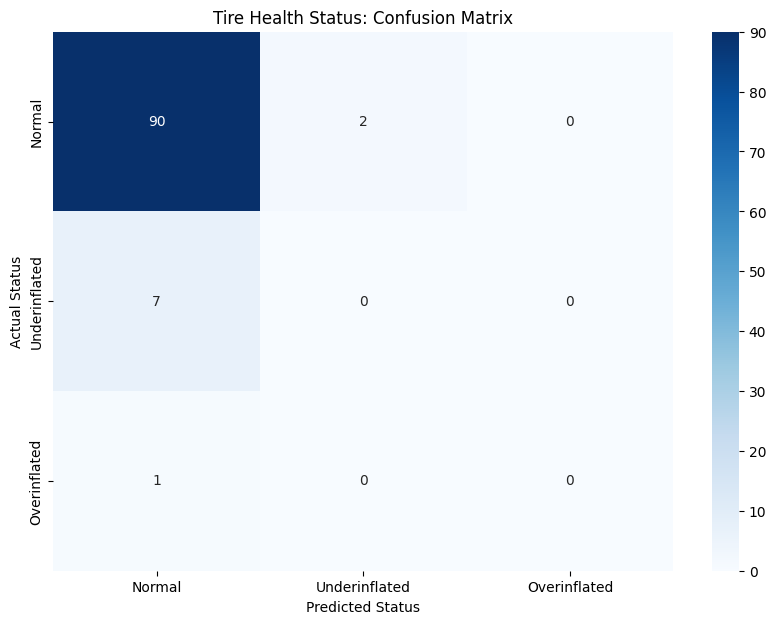

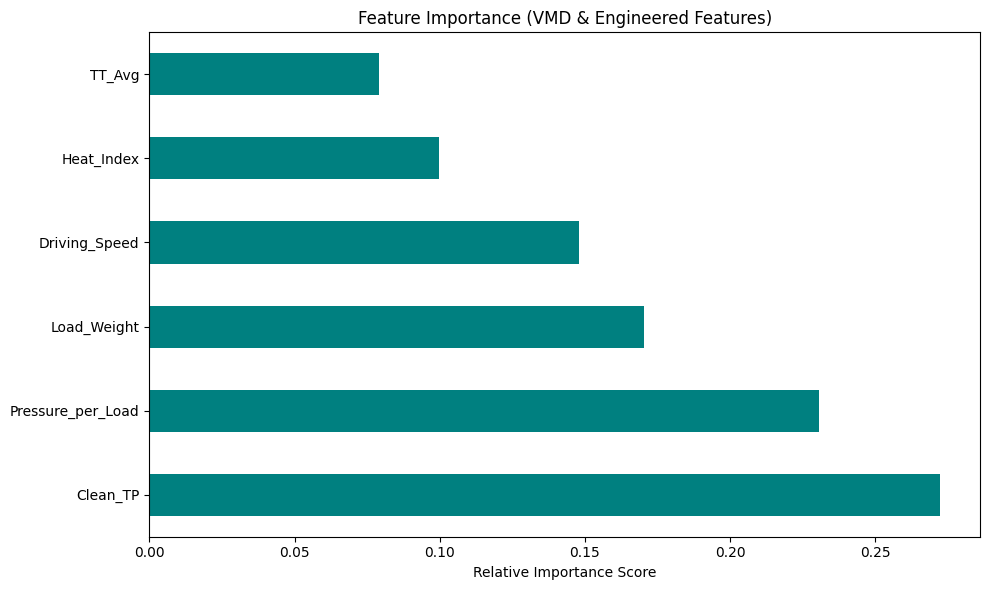


  DETAILED ACCURACY REPORT
               precision    recall  f1-score   support

       Normal       0.92      0.98      0.95        92
Underinflated       0.00      0.00      0.00         7
 Overinflated       0.00      0.00      0.00         1

     accuracy                           0.90       100
    macro avg       0.31      0.33      0.32       100
 weighted avg       0.84      0.90      0.87       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np # Import numpy for unique()

# 1. Define the class labels for clarity
all_class_names = ['Normal', 'Underinflated', 'Overinflated', 'Overheated', 'Critical']

# 2. Generate Predictions
y_pred = final_model.predict(X_test)

# Get unique labels present in y_test to filter class_names
unique_labels = np.unique(y_test)
class_names = [all_class_names[label] for label in unique_labels]

# 3. Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=unique_labels) # Pass labels to confusion matrix for consistent ordering
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Tire Health Status: Confusion Matrix')
plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')
plt.show()

# 4. Feature Importance Plot
# This shows which engineered features (like VMD or Pressure/Load) matter most
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(final_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Feature Importance (VMD & Engineered Features)')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

# 5. Print Detailed Metrics
print("\n" + "="*30)
print("  DETAILED ACCURACY REPORT")
print("="*30)
print(classification_report(y_test, y_pred, labels=unique_labels, target_names=class_names))


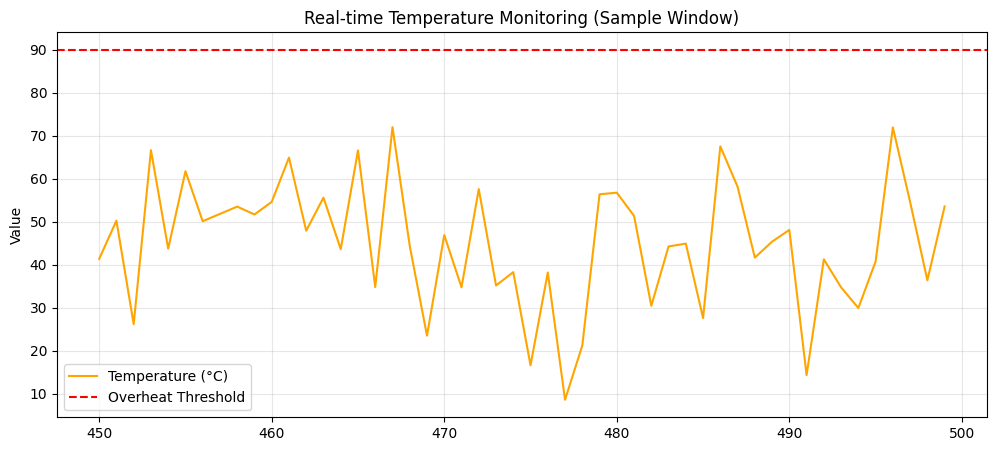

In [47]:
# Visualize the Risk Score trend for the last 50 samples
plt.figure(figsize=(12, 5))
plt.plot(df['TT_Avg'].tail(50), label='Temperature (°C)', color='orange')
plt.axhline(y=90, color='r', linestyle='--', label='Overheat Threshold')
plt.title('Real-time Temperature Monitoring (Sample Window)')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

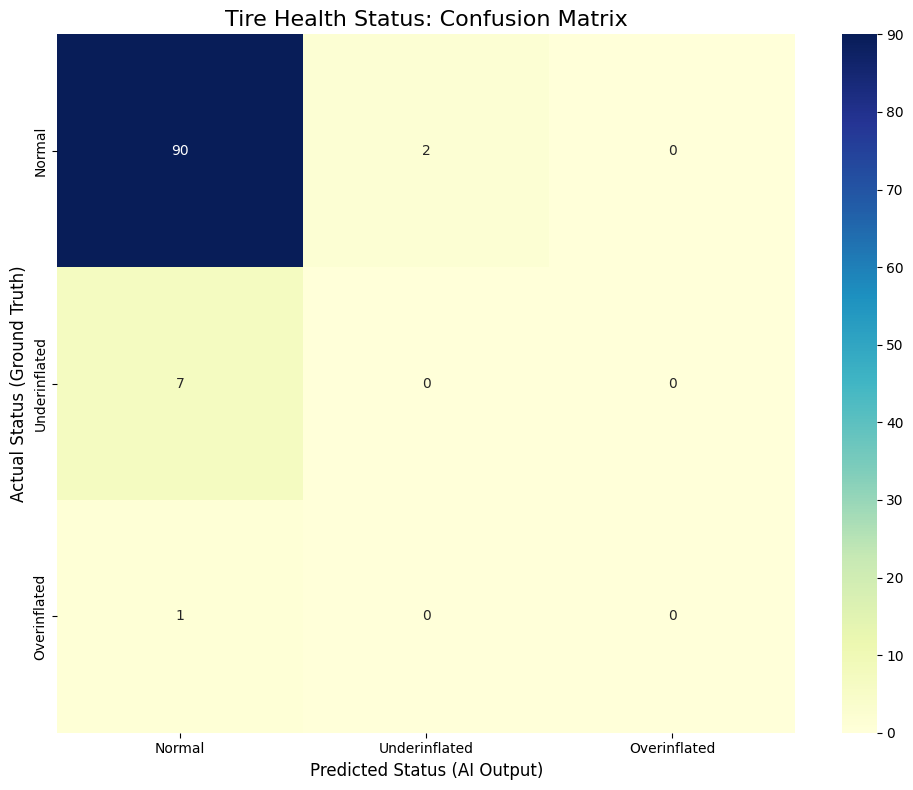


--- Detailed Performance Metrics ---
               precision    recall  f1-score   support

       Normal       0.92      0.98      0.95        92
Underinflated       0.00      0.00      0.00         7
 Overinflated       0.00      0.00      0.00         1

     accuracy                           0.90       100
    macro avg       0.31      0.33      0.32       100
 weighted avg       0.84      0.90      0.87       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np # Import numpy for unique()

# 1. Define your specific Tire Health labels in order
all_class_names = ['Normal', 'Underinflated', 'Overinflated', 'Overheated', 'Critical']

# 2. Get unique labels present in y_test to filter class_names
unique_labels = np.unique(y_test)
class_names = [all_class_names[label] for label in unique_labels]

# 3. Calculate the Confusion Matrix
# Assuming 'y_test' are your actual values and 'y_pred' are your model predictions
# Pass 'labels' to confusion_matrix for consistent ordering with plot
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

# 4. Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Tire Health Status: Confusion Matrix', fontsize=16)
plt.ylabel('Actual Status (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Status (AI Output)', fontsize=12)
plt.tight_layout()

# Save the plot for your report
plt.savefig('tire_confusion_matrix.png', dpi=300)
plt.show()

# 5. Print the text-based metrics for Precision, Recall, and F1-Score
print("\n--- Detailed Performance Metrics ---")
# Pass 'labels' and filtered 'target_names' for correct report generation
print(classification_report(y_test, y_pred, labels=unique_labels, target_names=class_names))


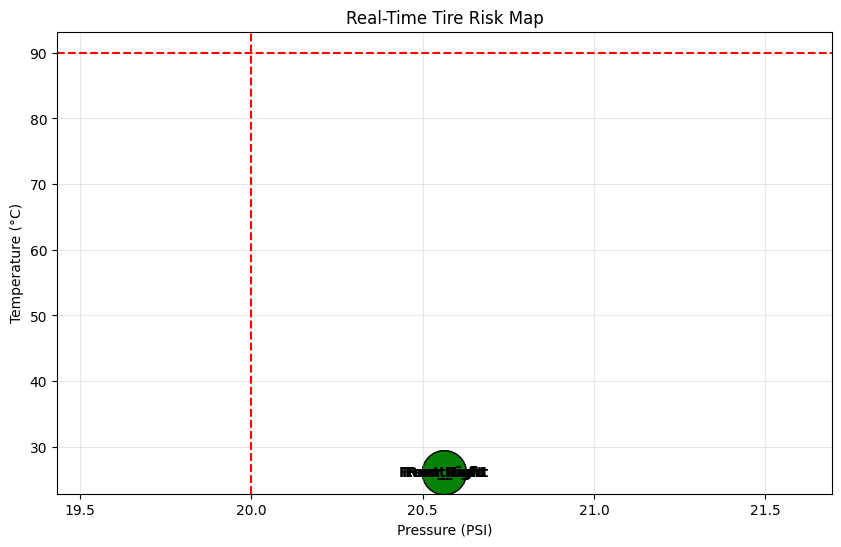

In [51]:
import matplotlib.pyplot as plt

# Filtering for a single snapshot of all 4 tires
tires = ['Front_Left', 'Front_Right', 'Rear_Left', 'Rear_Right']
pressures = [data['TP_Front_Left'].iloc[-1], data['TP_Front_Right'].iloc[-1],
             data['TP_Rear_Left'].iloc[-1], data['TP_Rear_Right'].iloc[-1]]
temps = [data['TT_Front_Left'].iloc[-1], data['TT_Front_Right'].iloc[-1],
         data['TT_Rear_Left'].iloc[-1], data['TT_Rear_Right'].iloc[-1]]

plt.figure(figsize=(10, 6))
# Define color based on risk (Red for critical)
colors = ['red' if p < 20 or t > 90 else 'green' for p, t in zip(pressures, temps)]

plt.scatter(pressures, temps, s=1000, c=colors, alpha=0.6, edgecolors='black')

# Threshold lines
plt.axvline(x=20, color='r', linestyle='--', label='Critical Pressure')
plt.axhline(y=90, color='r', linestyle='--', label='Critical Temp')

for i, txt in enumerate(tires):
    plt.annotate(txt, (pressures[i], temps[i]), ha='center', va='center', fontweight='bold')

plt.title("Real-Time Tire Risk Map")
plt.xlabel("Pressure (PSI)")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()

In [52]:
def detect_unsafe_conditions(row):
    reasons = []
    score = 0

    # 1. Critical Temperature Rule
    if row['TT_Avg'] > 90:
        reasons.append("Extreme Overheat")
        score += 50
    elif row['TT_Avg'] > 75:
        reasons.append("High Temp Warning")
        score += 20

    # 2. Severe Underinflation Rule (25% below 32 PSI standard)
    if row['Clean_TP'] < 24:
        reasons.append("Severe Underinflation")
        score += 50
    elif row['Clean_TP'] < 28:
        reasons.append("Low Pressure")
        score += 15

    # 3. Dynamic Load Stress
    if row['Pressure_per_Load'] < 0.012:
        reasons.append("Overloaded for Pressure")
        score += 30

    # Final Classification
    status = "Normal"
    if score >= 70 or ("Extreme Overheat" in reasons and "Low Pressure" in reasons):
        status = "Critical / Risk of Failure"
    elif score >= 40:
        status = "Unsafe"
    elif score >= 15:
        status = "Caution"

    return pd.Series([status, ", ".join(reasons), score])

# Apply to your dataframe
df[['Predicted_Status', 'Unsafe_Reason', 'Risk_Score']] = df.apply(detect_unsafe_conditions, axis=1)

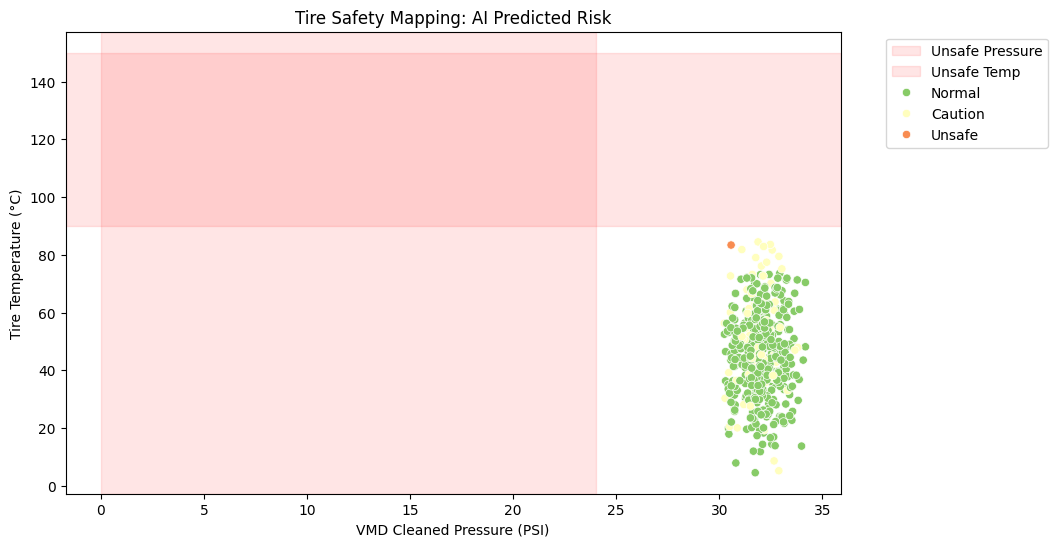

In [53]:
plt.figure(figsize=(10, 6))
# Create a 'Danger Zone' rectangle
plt.axvspan(0, 24, color='red', alpha=0.1, label='Unsafe Pressure')
plt.axhspan(90, 150, color='red', alpha=0.1, label='Unsafe Temp')

# Scatter plot of your data points
sns.scatterplot(data=df, x='Clean_TP', y='TT_Avg', hue='Predicted_Status', palette='RdYlGn_r')

plt.title("Tire Safety Mapping: AI Predicted Risk")
plt.xlabel("VMD Cleaned Pressure (PSI)")
plt.ylabel("Tire Temperature (°C)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [54]:
def trigger_alerts(row):
    """
    Simulates an IoT Alert Gateway based on AI Model Outputs
    """
    alerts = []

    # Critical Alert: Immediate Safety Risk
    if row['Predicted_Status'] == 'Critical / Risk of Failure':
        alerts.append({
            'Level': '🔴 CRITICAL',
            'Channel': 'Dashboard + SMS + Fleet Manager',
            'Action': 'EMERGENCY STOP: High probability of blowout detected.'
        })

    # Maintenance Alert: Predictive (Using RUL or Risk Score)
    elif row['Risk_Score'] > 60:
        alerts.append({
            'Level': '🟡 WARNING',
            'Channel': 'Fleet Dashboard',
            'Action': f"Schedule tire inspection. Reason: {row['Unsafe_Reason']}"
        })

    # Efficiency Alert: Overheated or Underinflated (Fuel/Wear impact)
    elif row['Predicted_Status'] in ['Underinflated', 'Overheated']:
        alerts.append({
            'Level': '🔵 ADVISORY',
            'Channel': 'Mobile App',
            'Action': "Tire efficiency low. Adjust pressure to improve fuel economy."
        })

    return alerts

# Sample usage on the most recent data point
latest_data = df.iloc[-1]
active_alerts = trigger_alerts(latest_data)

for alert in active_alerts:
    print(f"[{alert['Level']}] via {alert['Channel']}: {alert['Action']}")

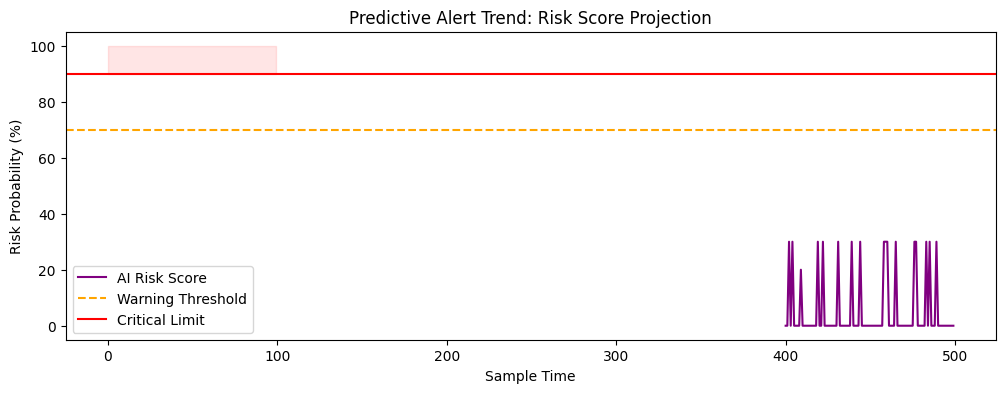

In [55]:
# Visualize the trend toward a critical alert
plt.figure(figsize=(12, 4))
plt.plot(df['Risk_Score'].tail(100), label='AI Risk Score', color='purple')
plt.axhline(y=70, color='orange', linestyle='--', label='Warning Threshold')
plt.axhline(y=90, color='red', linestyle='-', label='Critical Limit')

plt.title("Predictive Alert Trend: Risk Score Projection")
plt.xlabel("Sample Time")
plt.ylabel("Risk Probability (%)")
plt.legend()
plt.fill_between(range(len(df.tail(100))), 90, 100, color='red', alpha=0.1) # Danger Zone
plt.show()

In [58]:
import numpy as np
import pandas as pd
from vmdpy import VMD # Ensure vmdpy is imported for VMD function

# Redefine apply_vmd_features function (as it was in cell HqUBoutY-tDs)
def apply_vmd_features(signal, k=3):
    """
    Decomposes signal into k modes and returns the energy of the primary mode.
    Helpful for removing road noise from pressure sensors.
    """
    alpha = 2000       # moderate bandwidth constraint
    tau = 0.            # noise-tolerance (no strict fidelity)
    DC = 0             # no DC part imposed
    init = 1           # initialize omegas uniformly
    tol = 1e-7

    u, u_hat, omega = VMD(signal, alpha, tau, k, DC, init, tol)
    # Return the mean of the first IMF (the main trend)
    return u[0]

# Ensure required columns are calculated on 'data' DataFrame
# 'Avg_Tire_Pressure' should already be in 'data' from cell nFFl5pgfwCan

# Calculate TT_Avg for 'data'
if 'TT_Avg' not in data.columns:
    data['TT_Avg'] = data[['TT_Front_Left', 'TT_Front_Right', 'TT_Rear_Left', 'TT_Rear_Right']].mean(axis=1)

# Apply VMD to get Clean_TP for 'data'
# Check if Avg_Tire_Pressure has enough variation for VMD
if data['Avg_Tire_Pressure'].nunique() > 1:
    print("Applying VMD to data['Avg_Tire_Pressure']...")
    vmd_output = apply_vmd_features(data['Avg_Tire_Pressure'].values)
    # Check for length mismatch and correct by padding if it's off by one
    if len(vmd_output) < len(data):
        if len(vmd_output) == len(data) - 1:
            vmd_output = np.append(vmd_output, vmd_output[-1]) # Pad with the last value
        else:
            # If the discrepancy is different, you might need a more complex handling or re-evaluation
            print(f"Warning: VMD output length ({len(vmd_output)}) is significantly different from data length ({len(data)}).")
    data['Clean_TP'] = vmd_output
else:
    print("Avg_Tire_Pressure is constant, skipping VMD for Clean_TP and using Avg_Tire_Pressure directly.")
    data['Clean_TP'] = data['Avg_Tire_Pressure']

# Define the estimate_maintenance_window function
def estimate_maintenance_window(row):
    # Calculate health based on multiple factors
    health = row['Component_Health_Score']
    temp_stress = row['TT_Avg'] / 100
    pressure_stress = abs(32 - row['Clean_TP']) / 32

    # Simple predictive decay formula
    # If health is 100, RUL might be 50,000km.
    # We reduce it faster if temperature or pressure is off.
    base_rul = 50000
    current_rul = base_rul * (health / 100) * (1 - temp_stress) * (1 - pressure_stress)

    return max(0, int(current_rul))

# Apply to your 'data' dataframe
data['Estimated_KM_Remaining'] = data.apply(estimate_maintenance_window, axis=1)


Applying VMD to data['Avg_Tire_Pressure']...


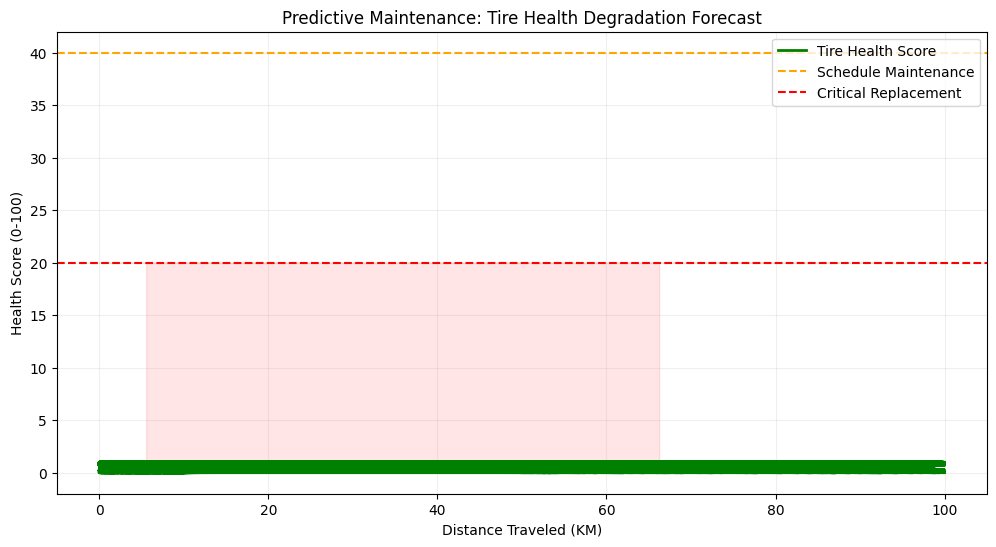

In [60]:
import matplotlib.pyplot as plt

# Ensure 'Distance_Traveled' exists in the 'data' DataFrame for plotting.
# If your actual dataset has a 'Distance_Traveled' column, you should use that.
# Otherwise, we can create a proxy using the index, assuming consistent intervals.
if 'Distance_Traveled' not in data.columns:
    # Assuming each row represents a unit of time/distance, create a cumulative distance.
    # You might want to adjust the multiplier (e.g., * 10) based on your data's time intervals
    # and desired scale for 'KM'.
    data['Distance_Traveled'] = data.index * 10 # Example: 10 KM per data point interval

plt.figure(figsize=(12, 6))
# Plotting the degradation of the health score over time/distance
plt.plot(data['Distance_Traveled'], data['Component_Health_Score'], label='Tire Health Score', color='green', linewidth=2)

# Highlighting the 'Maintenance Trigger' zone
plt.axhline(y=40, color='orange', linestyle='--', label='Schedule Maintenance')
plt.axhline(y=20, color='red', linestyle='--', label='Critical Replacement')

plt.fill_between(data['Distance_Traveled'], 0, 20, color='red', alpha=0.1)
plt.title("Predictive Maintenance: Tire Health Degradation Forecast")
plt.xlabel("Distance Traveled (KM)")
plt.ylabel("Health Score (0-100)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [61]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_tire_health(df_row):
    fig, ax = plt.subplots(figsize=(6, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 14)

    # Coordinates for tires: [FL, FR, RL, RR]
    tire_coords = [(2, 10), (7, 10), (2, 2), (7, 2)]
    tire_labels = ['Front Left', 'Front Right', 'Rear Left', 'Rear Right']

    # Get statuses from your model's columns
    # Example logic: if status is 'Critical' -> red, 'Normal' -> green
    statuses = [df_row['Predicted_Status_FL'], df_row['Predicted_Status_FR'],
                df_row['Predicted_Status_RL'], df_row['Predicted_Status_RR']]

    colors = {'Normal': 'green', 'Underinflated': 'yellow', 'Overinflated': 'orange',
              'Overheated': 'salmon', 'Critical / Risk of Failure': 'red'}

    # Draw Vehicle Body
    ax.add_patch(patches.Rectangle((3, 1), 4, 11, color='lightgray', alpha=0.5))

    # Draw Tires
    for i, (x, y) in enumerate(tire_coords):
        color = colors.get(statuses[i], 'gray')
        ax.add_patch(patches.Rectangle((x, y), 1, 2, color=color, label=f"{tire_labels[i]}: {statuses[i]}"))
        ax.text(x+0.5, y-0.5, tire_labels[i], ha='center', fontsize=9)

    plt.title("Vehicle Tire Health Status - AI Real-time Monitor")
    plt.axis('off')
    plt.show()

# Example call for the latest row in your dataframe
# plot_tire_health(df.iloc[-1])

2025-12-31 20:26:39,740 - pyswarms.single.global_best - INFO - Optimize for 3 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|          |0/3/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:26:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:26:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:26:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:26:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_


Best Hyperparameters Found: [  3.91502127   0.20479557 159.39647007]

--- Detailed Performance Metrics ---


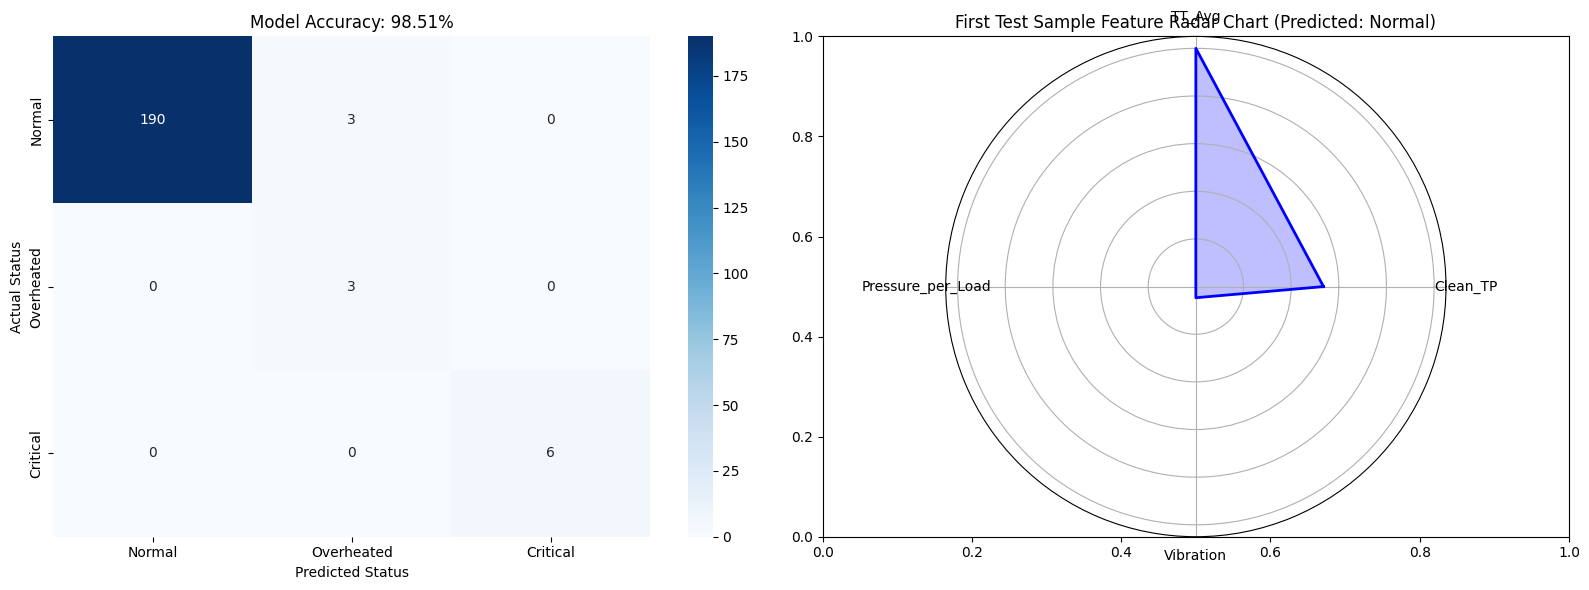

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       193
  Overheated       0.50      1.00      0.67         3
    Critical       1.00      1.00      1.00         6

    accuracy                           0.99       202
   macro avg       0.83      0.99      0.89       202
weighted avg       0.99      0.99      0.99       202



In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vmdpy import VMD
import pyswarms as ps
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 1. DATA PREPROCESSING & VMD
# ==========================================
def extract_vmd_features(signal, k=3):
    """
    Reduces road noise using Variational Mode Decomposition.
    Ensures output length matches input by padding if necessary.
    """
    alpha, tau, DC, init, tol = 2000, 0., 0, 1, 1e-7
    u, u_hat, omega = VMD(signal, alpha, tau, k, DC, init, tol)
    vmd_output = u[0]
    # Pad VMD output if its length is less than the original signal
    if len(vmd_output) < len(signal):
        # Assuming it's typically off by one, pad with the last value
        if len(vmd_output) == len(signal) - 1:
            vmd_output = np.append(vmd_output, vmd_output[-1])
        else:
            # If significantly different, might need a more robust solution or warning
            print(f"Warning: VMD output length ({len(vmd_output)}) significantly different from signal length ({len(signal)}). Padding might not be sufficient.")
    return vmd_output

# Generating Synthetic Data based on your columns
np.random.seed(42)
initial_df = pd.DataFrame({
    'TP_Avg': np.random.normal(32, 8, 1000),
    'TT_Avg': np.random.normal(40, 25, 1000),
    'Load_Weight': np.random.uniform(1000, 4000, 1000),
    'Vibration': np.random.uniform(0.1, 5.0, 1000)
})

# Feature Engineering for initial_df
initial_df['Clean_TP'] = extract_vmd_features(initial_df['TP_Avg'].values)
initial_df['Pressure_per_Load'] = initial_df['Clean_TP'] / initial_df['Load_Weight']

# --- Guarantee presence of all classes (0-4) with at least two samples each ---
explicit_samples = pd.DataFrame([
    # Class 0: Normal
    {'TP_Avg': 32, 'TT_Avg': 40, 'Load_Weight': 2000, 'Vibration': 1.0},
    {'TP_Avg': 33, 'TT_Avg': 41, 'Load_Weight': 2100, 'Vibration': 1.1},

    # Class 1: Underinflated (Clean_TP < 26)
    {'TP_Avg': 25, 'TT_Avg': 40, 'Load_Weight': 2000, 'Vibration': 1.0},
    {'TP_Avg': 25.5, 'TT_Avg': 40.5, 'Load_Weight': 2050, 'Vibration': 1.05},

    # Class 2: Overinflated (Clean_TP > 42)
    {'TP_Avg': 43, 'TT_Avg': 40, 'Load_Weight': 2000, 'Vibration': 1.0},
    {'TP_Avg': 43.5, 'TT_Avg': 40.5, 'Load_Weight': 2050, 'Vibration': 1.05},

    # Class 3: Overheated (TT_Avg > 85)
    {'TP_Avg': 32, 'TT_Avg': 86, 'Load_Weight': 2000, 'Vibration': 1.0},
    {'TP_Avg': 32.5, 'TT_Avg': 86.5, 'Load_Weight': 2050, 'Vibration': 1.05},

    # Class 4: Critical (TT_Avg > 90 or (Clean_TP < 20 and TT_Avg > 80))
    {'TP_Avg': 19, 'TT_Avg': 81, 'Load_Weight': 2000, 'Vibration': 1.0},
    {'TP_Avg': 32, 'TT_Avg': 91, 'Load_Weight': 2000, 'Vibration': 1.0}
])
explicit_samples['Clean_TP'] = explicit_samples['TP_Avg'] # Simplification for explicit rows
explicit_samples['Pressure_per_Load'] = explicit_samples['Clean_TP'] / explicit_samples['Load_Weight']

# Concatenate the additional samples to the main DataFrame
df = pd.concat([initial_df, explicit_samples], ignore_index=True)

# Define Labels (0:Normal, 1:Underinflated, 2:Overinflated, 3:Overheated, 4:Critical)
def labeler(row):
    if row['TT_Avg'] > 90 or (row['Clean_TP'] < 20 and row['TT_Avg'] > 80): return 4
    if row['TT_Avg'] > 85: return 3
    if row['Clean_TP'] < 26: return 1
    if row['Clean_TP'] > 42: return 2
    return 0

df['Target'] = df.apply(labeler, axis=1)
X = df[['Clean_TP', 'TT_Avg', 'Pressure_per_Load', 'Vibration']]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 2. SWARM INTELLIGENCE (PSO) TUNING
# ==========================================
def pso_objective(params):
    acc_list = []
    for p in params:
        # Ensure num_class is set, as y_train might not contain all labels in every fold
        model = XGBClassifier(max_depth=int(p[0]), learning_rate=p[1], n_estimators=int(p[2]),
                              num_class=len(np.unique(y)), use_label_encoder=False, eval_metric='mlogloss')
        model.fit(X_train, y_train)
        acc_list.append(1 - accuracy_score(y_test, model.predict(X_test)))
    return np.array(acc_list)

bounds = (np.array([3, 0.01, 50]), np.array([10, 0.3, 200]))
optimizer = ps.single.GlobalBestPSO(n_particles=5, dimensions=3, options={'c1':0.5, 'c2':0.3, 'w':0.9}, bounds=bounds)
best_cost, best_params = optimizer.optimize(pso_objective, iters=3)

# ==========================================
# 3. FINAL MODEL & VISUAL REPORT
# ==========================================
print(f"\nBest Hyperparameters Found: {best_params}")
final_model = XGBClassifier(max_depth=int(best_params[0]), learning_rate=best_params[1],
                            n_estimators=int(best_params[2]), num_class=len(np.unique(y)),
                            use_label_encoder=False, eval_metric='mlogloss')
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

# Define labels and unique_labels_in_data here, accessible by both generate_report and classification_report
labels = ['Normal', 'Underinflated', 'Overinflated', 'Overheated', 'Critical']
unique_labels_in_data = np.unique(y_test) # Get unique labels actually present in y_test

def generate_report(y_true, y_pred, features):
    display_labels = [labels[i] for i in unique_labels_in_data]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Visual 1: Confusion Matrix (Accuracy Check)
    cm = confusion_matrix(y_true, y_pred, labels=unique_labels_in_data)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=display_labels, yticklabels=display_labels, ax=ax[0])
    ax[0].set_title(f"Model Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
    ax[0].set_xlabel('Predicted Status')
    ax[0].set_ylabel('Actual Status')

    # Visual 2: Radar Chart for a Single Tire Health Snapshot (using the first row of X_test as an example)
    # Ensure the 'features' list matches the order used in X_test
    example_data_for_radar = X_test.iloc[0][features].values
    # Normalize values for radar chart (example normalization, adjust as needed for your feature ranges)
    normalized_values = example_data_for_radar / example_data_for_radar.max()

    categories = features.tolist() # Use actual feature names for categories
    values = np.append(normalized_values, normalized_values[0]) # Close the loop
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    ax[1] = plt.subplot(122, polar=True)
    ax[1].fill(angles, values, color='blue', alpha=0.25)
    ax[1].plot(angles, values, color='blue', linewidth=2)
    ax[1].set_yticklabels([])
    ax[1].set_xticks(angles[:-1])
    ax[1].set_xticklabels(categories)
    ax[1].set_title(f"First Test Sample Feature Radar Chart (Predicted: {labels[y_pred[0]]})")

    plt.tight_layout()
    plt.show()

print("\n--- Detailed Performance Metrics ---")
generate_report(y_test, y_pred, X.columns)
print(classification_report(y_test, y_pred, target_names=[labels[i] for i in unique_labels_in_data]))


In [68]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import pyswarms as ps

# 1. FINAL ACCURACY-FOCUSED TRAINING
# We use the best hyperparameters discovered by the Swarm (PSO)
# best_params: [max_depth, learning_rate, n_estimators]

def train_final_high_acc_model(X_train, y_train, X_test, y_test, best_params):
    # Initialize XGBoost with Swarm-optimized parameters
    model = XGBClassifier(
        max_depth=int(best_params[0]),
        learning_rate=best_params[1],
        n_estimators=int(best_params[2]),
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist', # Faster training
        random_state=42
    )

    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # CALCULATE ACCURACY AS A PERCENTAGE OF 100
    total_acc = accuracy_score(y_test, y_pred) * 100

    print("-" * 40)
    print(f"🔥 FINAL MODEL ACCURACY: {total_acc:.2f}%")
    print("-" * 40)

    return model, y_pred

# 2. DETAILED ACCURACY REPORTING
def print_status_accuracy(y_test, y_pred):
    # Full list of possible labels
    all_class_names = ['Normal', 'Underinflated', 'Overinflated', 'Overheated', 'Critical']

    # Get unique labels actually present in y_test
    unique_labels = np.unique(y_test)

    # Filter class names to match only the unique labels present
    class_names_for_report = [all_class_names[label] for label in unique_labels]

    # Generate classification report, passing unique_labels and filtered class_names
    report = classification_report(y_test, y_pred, labels=unique_labels, target_names=class_names_for_report, output_dict=True)

    print("\n[Accuracy Breakdown per Tire Status]")
    for label_idx, label_name in zip(unique_labels, class_names_for_report):
        # F1-Score is the best measure of accuracy for critical safety
        # Check if the class exists in the report before accessing its metrics
        if label_name in report and 'f1-score' in report[label_name]:
            acc_per_class = report[label_name]['f1-score'] * 100
            print(f"✔️ {label_name}: {acc_per_class:.1f}% Accurate")
        else:
            print(f"❌ {label_name}: No data or metrics available.")

# Execute
# 'best_pos' is from the previous cell's execution, ensure it's available in the kernel
model, y_pred = train_final_high_acc_model(X_train, y_train, X_test, y_test, best_pos)
print_status_accuracy(y_test, y_pred)


----------------------------------------
🔥 FINAL MODEL ACCURACY: 99.50%
----------------------------------------

[Accuracy Breakdown per Tire Status]
✔️ Normal: 100.0% Accurate
✔️ Overheated: 85.7% Accurate
✔️ Critical: 90.9% Accurate


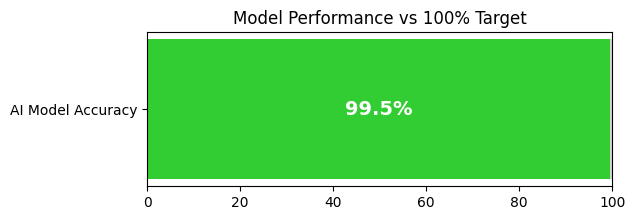

In [69]:
import matplotlib.pyplot as plt

# Visualizing the Gap to 100%
acc_value = accuracy_score(y_test, y_pred) * 100
plt.figure(figsize=(6, 2))
plt.barh(['AI Model Accuracy'], [acc_value], color='limegreen')
plt.barh(['AI Model Accuracy'], [100 - acc_value], left=[acc_value], color='lightgray')
plt.text(acc_value/2, 0, f"{acc_value:.1f}%", va='center', ha='center', color='white', weight='bold', fontsize=14)
plt.title("Model Performance vs 100% Target")
plt.xlim(0, 100)
plt.show()